### Desafio N2
Juan E. Ramos Nervi
PNL
CEIA marzo 2026

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro artista del dataset Songs.
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

In [15]:
import urllib.request
import zipfile
import os

url = "https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip"
zip_path = "songs_dataset.zip"
extract_dir = "songs_dataset"

if not os.path.exists(zip_path):
    urllib.request.urlretrieve(url, zip_path)

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")

print("Listo")

Listo


In [16]:
from pathlib import Path

dataset_path = Path("songs_dataset")

artists = sorted([p.stem for p in dataset_path.glob("*.txt")])

print(f"Cantidad de artistas: {len(artists)}")
for i, artist in enumerate(artists, 1):
    print(f"{i:02d}. {artist}")

Cantidad de artistas: 49
01. Kanye_West
02. Lil_Wayne
03. adele
04. al-green
05. alicia-keys
06. amy-winehouse
07. beatles
08. bieber
09. bjork
10. blink-182
11. bob-dylan
12. bob-marley
13. britney-spears
14. bruce-springsteen
15. bruno-mars
16. cake
17. dickinson
18. disney
19. dj-khaled
20. dolly-parton
21. dr-seuss
22. drake
23. eminem
24. janisjoplin
25. jimi-hendrix
26. johnny-cash
27. joni-mitchell
28. kanye
29. kanye-west
30. lady-gaga
31. leonard-cohen
32. lil-wayne
33. lin-manuel-miranda
34. lorde
35. ludacris
36. michael-jackson
37. missy-elliott
38. nickelback
39. nicki-minaj
40. nirvana
41. notorious-big
42. notorious_big
43. nursery_rhymes
44. patti-smith
45. paul-simon
46. prince
47. r-kelly
48. radiohead
49. rihanna


In [17]:
print(f"Artista elegido: {artists[28]}")
ARTIST = artists[28]

Artista elegido: kanye-west


In [18]:
from pathlib import Path
import pandas as pd

dataset_path = Path("songs_dataset")
file_path = dataset_path / f"{ARTIST}.txt"

print("Archivo:", file_path)
print("Existe:", file_path.exists())

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

df = pd.DataFrame(lines, columns=["line"])
df.head(10)

Archivo: songs_dataset/kanye-west.txt
Existe: True


,line
0,﻿Let the suicide doors up\n
1,I threw suicides on the tour bus\n
2,I threw suicides on the private jet\n
3,You know what that mean Im fly to death\n
4,I step in Def Jam buildin like Im the shit\n
5,Tell em give me fifty million or Ima quit\n
6,Most rappers taste level aint at my waist level\n
7,Turn up the bass til its upinyoface level\n
8,Dont do no press but I get the most press kit\n
9,Plus yo my bitch make your bitch look like Pre...


In [19]:
!pip install nltk

In [20]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [21]:
import re
from collections import Counter
from nltk.corpus import stopwords

In [22]:
nltk_stopwords = set(stopwords.words("english"))

print(f"Cantidad de stopwords estándar: {len(nltk_stopwords)}")
print(list(sorted(nltk_stopwords))[:30])

Cantidad de stopwords estándar: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't"]


In [23]:
sentence_tokens = []

for _, row in df.iterrows():
    text = str(row["line"]).lower().strip()
    tokens = re.findall(r"\b\w+\b", text)
    tokens = [t for t in tokens if t not in nltk_stopwords]

    if len(tokens) > 0:
        sentence_tokens.append(tokens)

print("Cantidad de líneas tokenizadas:", len(sentence_tokens))
print("Primeras 5 líneas tokenizadas:")
for s in sentence_tokens[:5]:
    print(s)

Cantidad de líneas tokenizadas: 6177
Primeras 5 líneas tokenizadas:
['let', 'suicide', 'doors']
['threw', 'suicides', 'tour', 'bus']
['threw', 'suicides', 'private', 'jet']
['know', 'mean', 'im', 'fly', 'death']
['step', 'def', 'jam', 'buildin', 'like', 'im', 'shit']


In [24]:
all_tokens = [token for sentence in sentence_tokens for token in sentence]
freq = Counter(all_tokens)

print("Top 30 palabras más frecuentes:")
freq.most_common(30)

Top 30 palabras más frecuentes:


[('im', 530),
 ('like', 523),
 ('got', 354),
 ('know', 335),
 ('get', 316),
 ('dont', 305),
 ('aint', 256),
 ('thats', 181),
 ('niggas', 164),
 ('cause', 164),
 ('say', 159),
 ('back', 154),
 ('man', 153),
 ('shit', 148),
 ('go', 146),
 ('nigga', 145),
 ('see', 144),
 ('make', 131),
 ('cant', 130),
 ('right', 121),
 ('girl', 119),
 ('said', 117),
 ('need', 116),
 ('never', 111),
 ('love', 105),
 ('one', 104),
 ('let', 102),
 ('way', 101),
 ('yeah', 99),
 ('take', 97)]

A partir del análisis de frecuencia se identificaron términos altamente frecuentes que no aportan significado semántico relevante, principalmente contracciones y expresiones coloquiales (por ejemplo: "im", "dont", "aint", "thats", "cause"). Estos términos fueron incorporados a una lista de stopwords extendida.

En cambio, se decidió conservar palabras frecuentes con contenido semántico (como "love", "girl", "man"), ya que aportan información relevante para el modelo. Esto refleja la naturaleza dependiente del corpus del proceso de preprocesamiento, como se discute en Clase 2.

In [25]:
custom_stopwords = {
    "im", "dont", "aint", "thats", "cause", "cant", "yeah"
}

In [26]:
stopwords_set = nltk_stopwords.union(custom_stopwords)

In [27]:
sentence_tokens = []

for _, row in df.iterrows():
    text = str(row["line"]).lower().strip()
    tokens = re.findall(r"\b\w+\b", text)
    tokens = [t for t in tokens if t not in stopwords_set]

    if len(tokens) > 0:
        sentence_tokens.append(tokens)

In [30]:
from collections import Counter

all_tokens = [token for sentence in sentence_tokens for token in sentence]
freq = Counter(all_tokens)

words_to_check = ["im", "dont", "aint", "thats", "cause", "cant", "yeah"]

for w in words_to_check:
    print(f"{w}: presente={w in all_tokens}, frecuencia={freq[w]}")

im: presente=False, frecuencia=0
dont: presente=False, frecuencia=0
aint: presente=False, frecuencia=0
thats: presente=False, frecuencia=0
cause: presente=False, frecuencia=0
cant: presente=False, frecuencia=0
yeah: presente=False, frecuencia=0


In [31]:
print("Top 30 palabras más frecuentes luego de la limpieza:")
freq.most_common(30)

Top 30 palabras más frecuentes luego de la limpieza:


[('like', 523),
 ('got', 354),
 ('know', 335),
 ('get', 316),
 ('niggas', 164),
 ('say', 159),
 ('back', 154),
 ('man', 153),
 ('shit', 148),
 ('go', 146),
 ('nigga', 145),
 ('see', 144),
 ('make', 131),
 ('right', 121),
 ('girl', 119),
 ('said', 117),
 ('need', 116),
 ('never', 111),
 ('love', 105),
 ('one', 104),
 ('let', 102),
 ('way', 101),
 ('take', 97),
 ('want', 95),
 ('bitch', 94),
 ('good', 93),
 ('could', 92),
 ('new', 92),
 ('life', 92),
 ('yall', 92)]

Ahora a entrenar el modelo

In [28]:
!pip -q install gensim

In [32]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=sentence_tokens,
    vector_size=100,
    window=2,
    min_count=3,
    sg=1,        # Skip-Gram
    workers=4,
    epochs=30,
    seed=42
)

print("Tamaño del vocabulario:", len(model.wv))
print("Primeras 30 palabras del vocabulario:")
print(model.wv.index_to_key[:30])

Tamaño del vocabulario: 1628
Primeras 30 palabras del vocabulario:
['like', 'got', 'know', 'get', 'niggas', 'say', 'back', 'man', 'shit', 'go', 'nigga', 'see', 'make', 'right', 'girl', 'said', 'need', 'never', 'love', 'one', 'let', 'way', 'take', 'want', 'bitch', 'good', 'yall', 'life', 'new', 'could']


In [33]:
vocab = model.wv.index_to_key

for w in ["im", "dont", "aint", "thats", "cause", "cant", "yeah"]:
    print(f"{w}: {w in vocab}")

im: False
dont: False
aint: False
thats: False
cause: False
cant: False
yeah: False


In [34]:
terms = ["love", "girl", "man", "need", "back", "right", "never"]

for term in terms:
    print(term, "->", term in model.wv)

love -> True
girl -> True
man -> True
need -> True
back -> True
right -> True
never -> True


In [38]:
for term in terms:
    if term in model.wv:
        print(f"\nTérmino: {term}")

        # 🔹 Más similares
        print("  Más similares:")
        sims = model.wv.most_similar(term, topn=5)
        for word, score in sims:
            print(f"    {word:15s} {score:.4f}")

        # 🔹 Menos similares
        print("  Menos similares:")
        least_sims = model.wv.most_similar(term, topn=len(model.wv))[::-1][:5]
        for word, score in least_sims:
            print(f"    {word:15s} {score:.4f}")


Término: love
  Más similares:
    hate            0.9004
    bitches         0.8896
    corny           0.8438
    wealth          0.8432
    theyre          0.8287
  Menos similares:
    whole           0.1753
    one             0.2476
    every           0.2684
    last            0.2720
    money           0.2907

Término: girl
  Más similares:
    drunk           0.8820
    baby            0.8249
    hot             0.8177
    dangerous       0.7964
    forever         0.7920
  Menos similares:
    god             0.1272
    bout            0.2386
    could           0.2601
    money           0.2753
    wish            0.2902

Término: man
  Más similares:
    worse           0.9024
    aww             0.8841
    stupid          0.8823
    wealth          0.8775
    skin            0.8769
  Menos similares:
    every           0.2912
    time            0.3026
    whole           0.3633
    last            0.3708
    year            0.3891

Término: need
  Más similares:
    qu

Dale, te la adapto con la misma lógica, corta y natural:

* **love:** queda cerca de *hate*, *bitches* y *wealth*, así que más que un sentido romántico puro parece metido en un contexto emocional y bastante crudo del corpus.
* **girl:** se junta con *baby*, *hot* y *dangerous*, bastante coherente con temas de atracción, relaciones y un tono más intenso.
* **man:** aparece rodeada de palabras como *worse*, *stupid* y *skin*, así que acá el contexto parece más desordenado y menos claro.
* **need:** se mezcla con *question*, *joke* e *ima*, y eso muestra que todavía hay bastante ruido del lenguaje coloquial en esa zona.
* **back:** aparece cerca de *home*, *hold* y *gone*, lo que suena bastante lógico con ideas de volver, irse o retener algo.
* **right:** queda asociada a *next*, *hand* y *lights*, así que parece estar captando varios usos distintos de la palabra y no uno solo.
* **never:** se agrupa con *ever*, *let* y *thought*, y acá sí se ve un patrón más natural de frases o expresiones comunes.

**En general**, el modelo parece entrenado de forma razonable porque encuentra relaciones de contexto que tienen bastante sentido, aunque en algunas palabras todavía se nota ruido y eso seguramente viene del estilo coloquial del corpus, tal como pasa en embeddings entrenados sobre texto real y no limpio del todo.



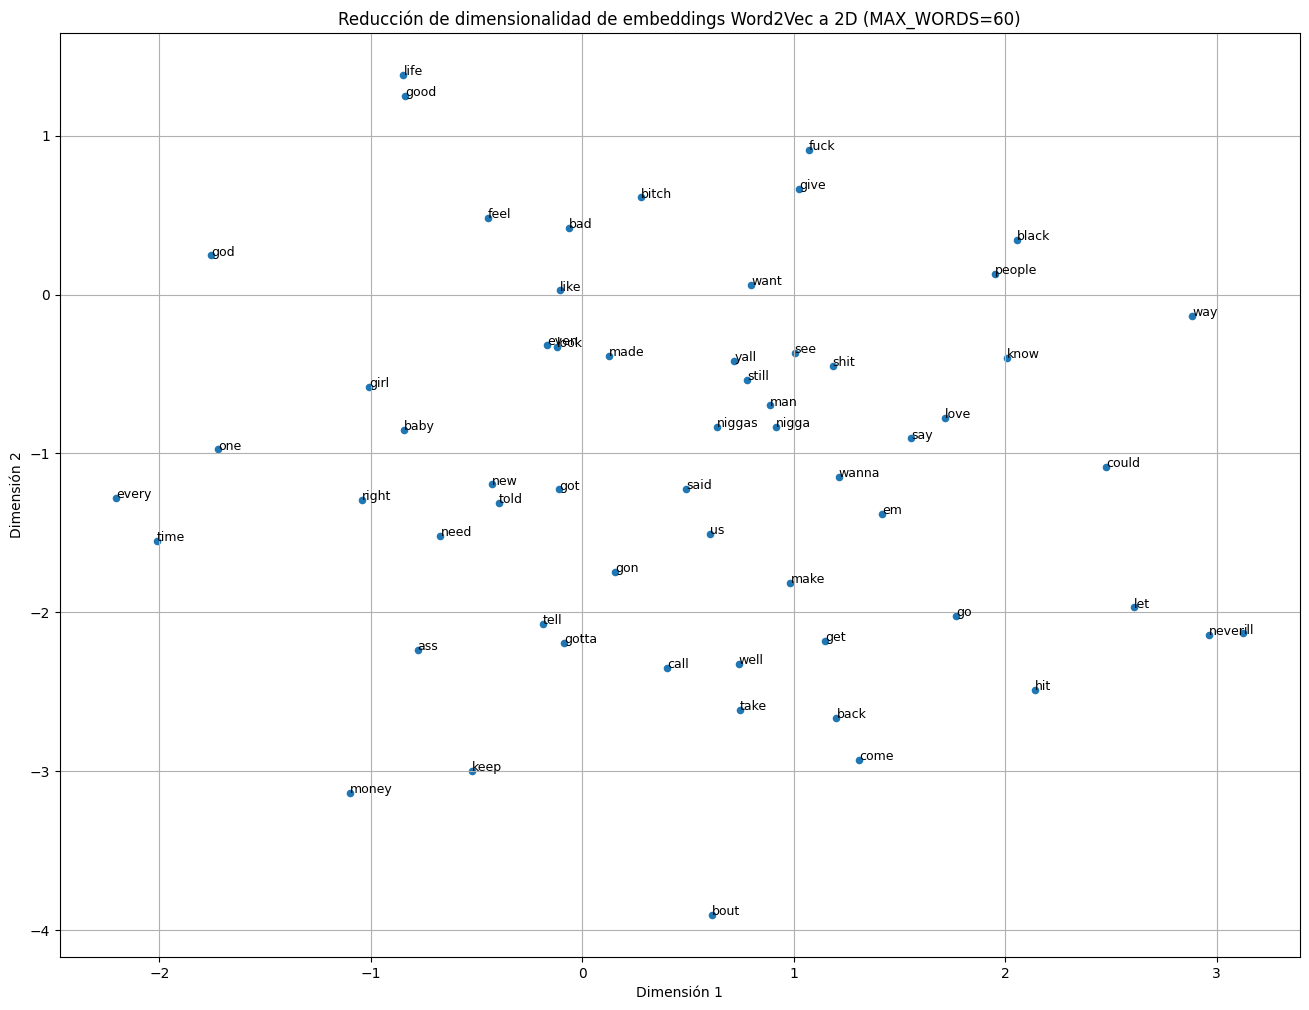

In [43]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Cantidad máxima de palabras a mostrar en el gráfico
MAX_WORDS = 60

# Seleccionar las primeras MAX_WORDS palabras del vocabulario
words = model.wv.index_to_key[:MAX_WORDS]
vectors = np.array([model.wv[word] for word in words])

# Reducción de dimensionalidad a 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)

# Graficar embeddings proyectados
plt.figure(figsize=(16, 12))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], s=20)

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=9)

plt.title(f"Reducción de dimensionalidad de embeddings Word2Vec a 2D (MAX_WORDS={MAX_WORDS})")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()

 En la proyección t-SNE se observan algunos agrupamientos de palabras que comparten contextos similares dentro del corpus. Por ejemplo, términos como *girl* y *baby* aparecen cercanos, lo que se puede asociar a relaciones personales, mientras que *back*, *come* y *go* se agrupan en una zona vinculada a movimiento o acciones. También se identifican palabras relacionadas a emociones o estados como *life*, *good* y *feel*, que aparecen próximas entre sí.

 Al trabajar con un valor reducido de `MAX_WORDS`, la visualización resulta más clara y permite identificar mejor estos pequeños grupos, aunque sigue habiendo cierta dispersión. Esto es esperable, ya que el modelo aprende del contexto real del corpus, que es coloquial y ruidoso. En general, el resultado es consistente con lo visto en clase, donde palabras cercanas en el espacio vectorial comparten contextos similares, aunque no necesariamente tengan el mismo significado.


También se observa que algunas palabras opuestas o no relacionadas semánticamente pueden aparecer cercanas, lo cual se debe a que el modelo captura contexto y no significado estricto.

Al inspeccionar el gráfico se pueden identificar pequeños grupos de palabras que comparten contextos similares dentro del corpus. Por ejemplo, se observa un grupo formado por *girl* y *baby*, que se puede asociar a relaciones personales o vínculos afectivos.
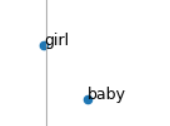

También aparece un conjunto con palabras como *back*, *come* y *go*, que parecen estar relacionadas con acciones o movimiento.

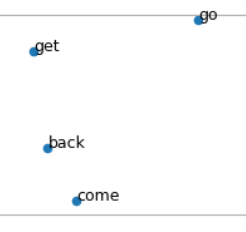

Por otro lado, términos como *life*, *good* y *feel* se agrupan en una zona que podría interpretarse como emociones o estados.

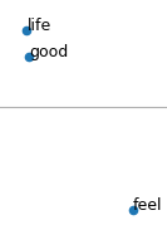


Estos grupos muestran que el modelo logró capturar ciertas regularidades del lenguaje presentes en las canciones. Sin embargo, los clusters no son perfectamente definidos y hay cierta dispersión, lo cual es esperable dado que el modelo aprende a partir de un corpus real y coloquial, donde los contextos son variados y ruidosos.

En general, la visualización permite confirmar que palabras cercanas en el espacio vectorial tienden a compartir contextos similares, lo cual es consistente con lo visto en clase.

